/home/szy/.conda/envs/maple/lib/python3.11/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


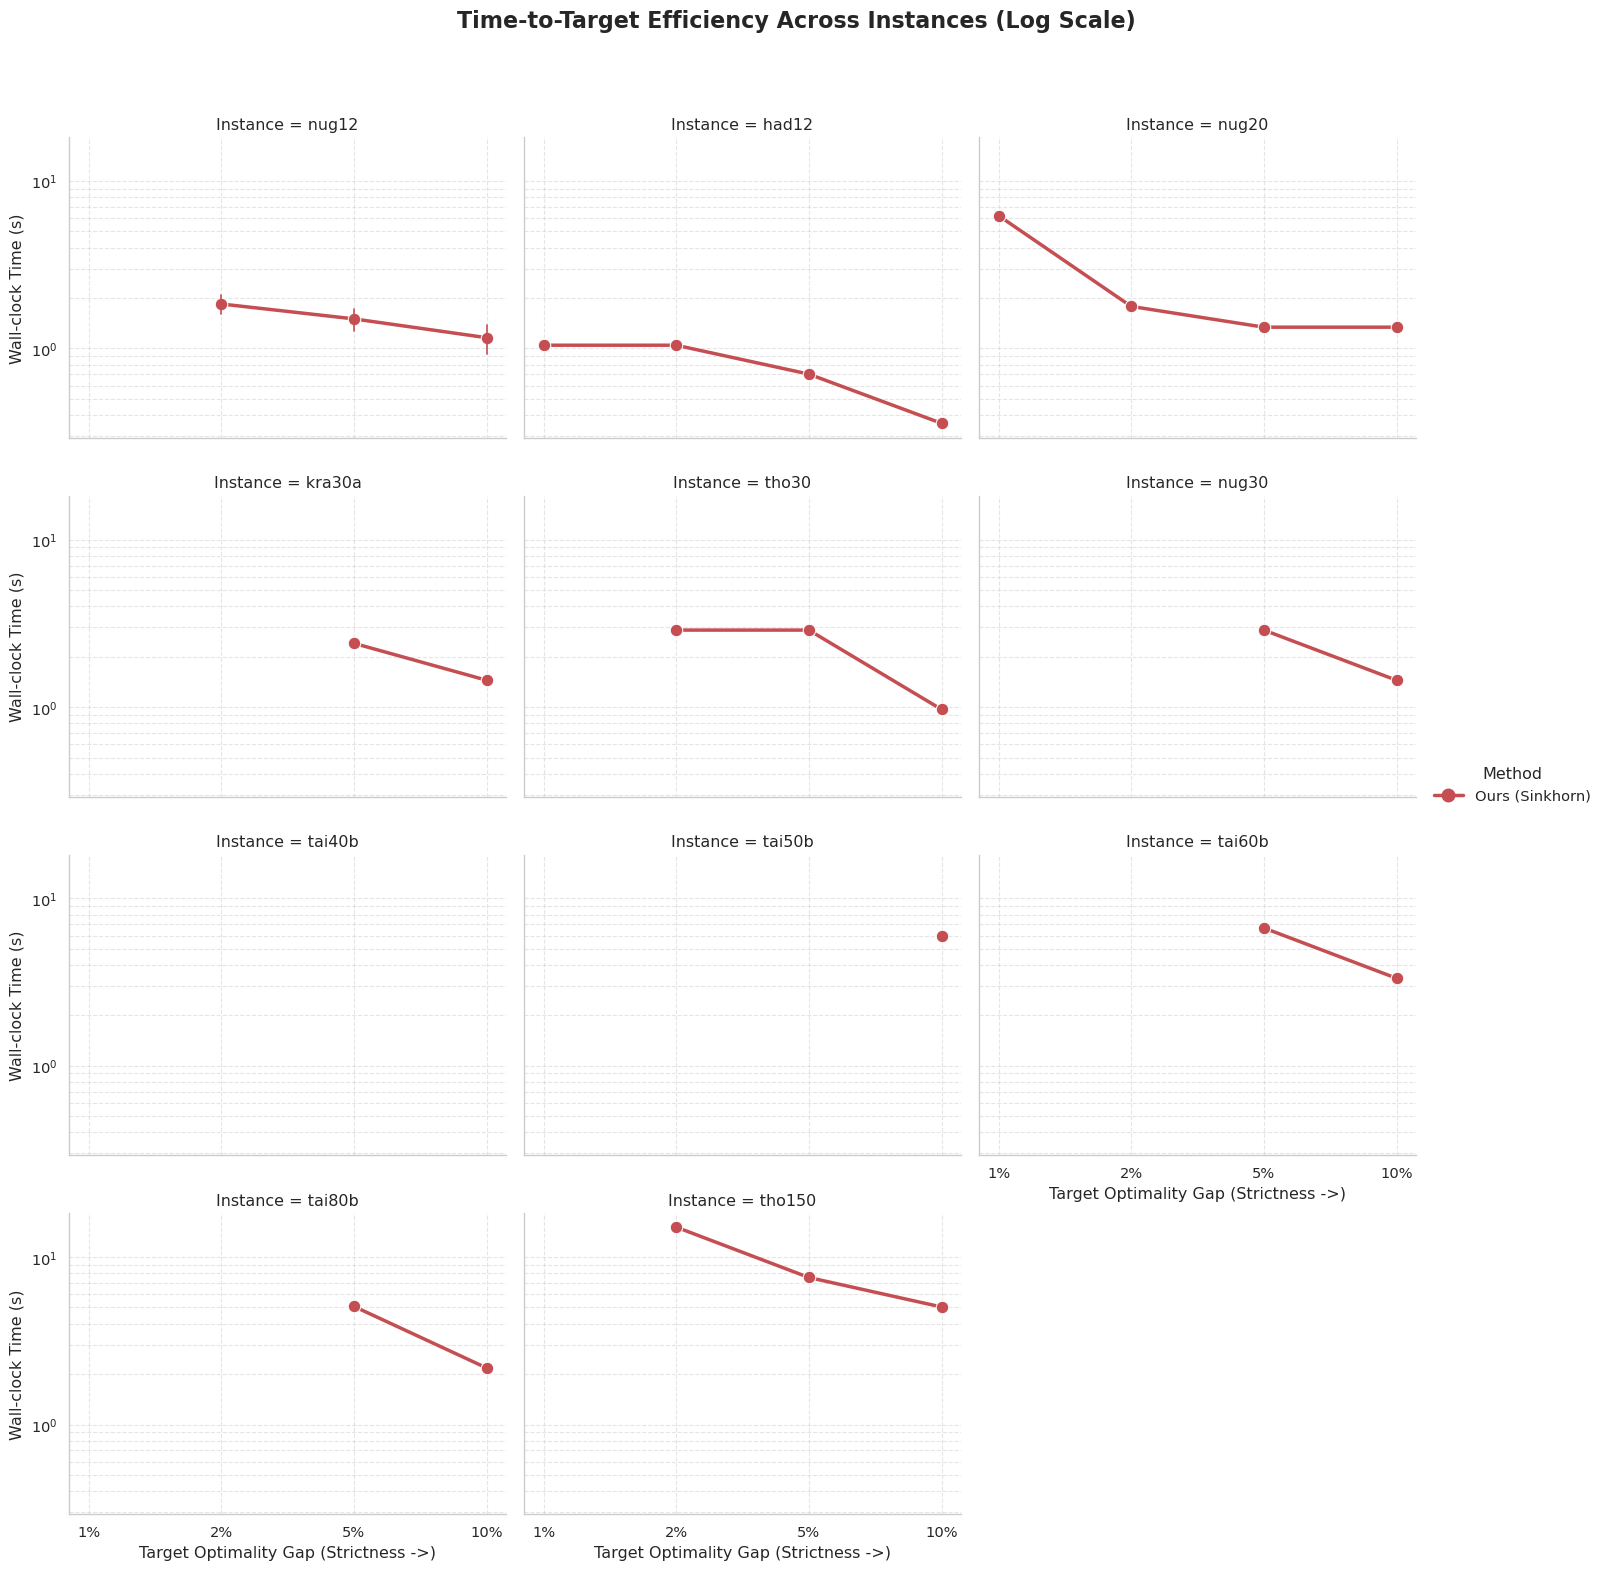

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取数据 (替换你的真实csv路径)
df = pd.read_csv("benchmark_result_time_analysis_20260119_142717.csv")

# 定义我们要分析的 Gap 阈值（列名后缀）
targets = ['10%', '5%', '2%', '1%'] 
plot_data = []

# 定义 Instance 的排序顺序（按 Size 从小到大，或者按你的 Difficulty Ladder）
# 这一步很重要，否则图会乱序
# 你可以根据 df 的 Size 列自动生成顺序
instance_order = df.sort_values('Size')['Instance'].unique()

for idx, row in df.iterrows():
    inst = row['Instance']
    size = row['Size']
    seed = row['Seed']
    
    for method in ['PGD', 'SK']:
        label = 'Baseline (PGD)' if method == 'PGD' else 'Ours (Sinkhorn)'
        
        for t in targets:
            col_name = f"{method}_T_to_{t}"
            
            # 检查列是否存在且有值
            if col_name in row and pd.notna(row[col_name]):
                val = row[col_name]
                plot_data.append({
                    'Instance': inst,
                    'Size': size,
                    'Seed': seed,
                    'Method': label,
                    'Target Gap': t,          # X轴分类
                    'Time (s)': val,          # Y轴数值
                    'Target_Num': float(t.strip('%')) # 用于排序的数值
                })

df_plot = pd.DataFrame(plot_data)

# ==========================================
# 3. 核心绘图：使用 relplot (FacetGrid)
# ==========================================

sns.set(style="whitegrid", context="paper", font_scale=1.2)

# 定义颜色：蓝 vs 红
palette = {'Baseline (PGD)': '#4c72b0', 'Ours (Sinkhorn)': '#c44e52'}

# 创建分面图
# col="Instance" 表示按算例分列
# col_wrap=3 表示每行画3个图，自动换行
# height=4, aspect=1.2 控制每个子图的大小
g = sns.relplot(
    data=df_plot,
    x="Target Gap", 
    y="Time (s)",
    hue="Method",
    style="Method",
    col="Instance",      # <--- 关键：按 Instance 分类
    col_order=instance_order, # 按规模排序
    col_wrap=3,          # 每行显示3个图
    kind="line",         # 折线图
    markers=True,
    dashes=False,
    height=4, 
    aspect=1.2,
    palette=palette,
    err_style="bars",    # 显示误差棒
    errorbar=("sd", 1),  # 标准差
    linewidth=2.5,
    markersize=9
)

# ==========================================
# 4. 美化调整
# ==========================================

# 对每个子图进行微调
for ax in g.axes.flatten():
    # 使用对数坐标，因为不同难度的时间跨度极大
    ax.set_yscale('log')
    # 反转X轴，让 10% 在左边，1% 在右边
    ax.invert_xaxis()
    #以此画出虚线网格
    ax.grid(True, which="both", ls="--", alpha=0.5)

# 设置总标题
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Time-to-Target Efficiency Across Instances (Log Scale)', fontsize=16, weight='bold')

# 修改轴标签
g.set_axis_labels("Target Optimality Gap (Strictness ->)", "Wall-clock Time (s)")

plt.show()

=== Drawing Convergence Trace for tho150 ===
Running PGD...
Running Sinkhorn...


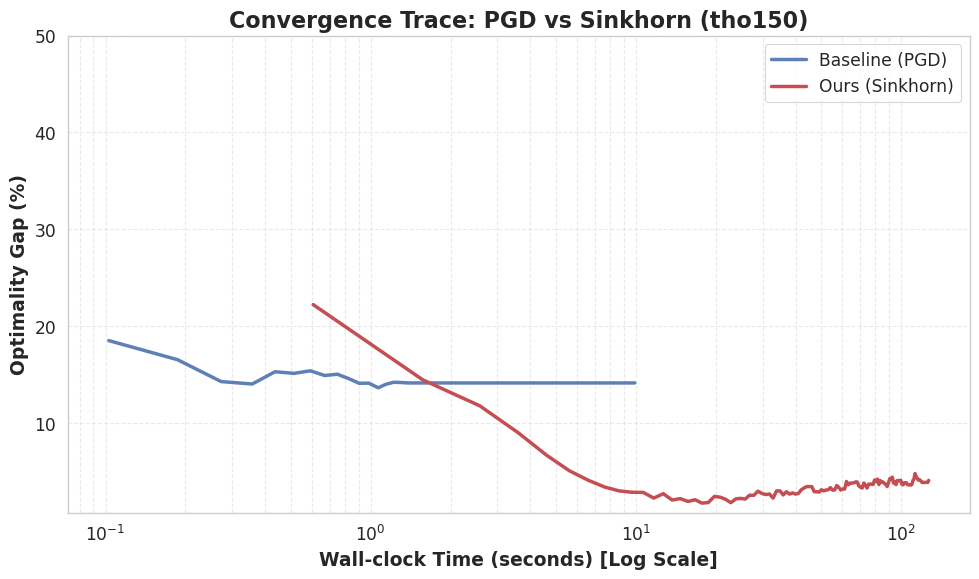

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
from solver.common import read_instance
from solver.pgd import PGDSolver
from solver.sinkhorn import SinkhornSolver
import config

# ==========================================
# 1. 设置战场 (选择一个有代表性的算例)
# ==========================================
# 建议选 kra30a (中等) 或 tai60b (困难，效果最震撼)
instance_name = 'tho150' 
seed = 0 # 固定种子

print(f"=== Drawing Convergence Trace for {instance_name} ===")

# 加载数据
n, F_np, D_np, _, _ = read_instance(instance_name)
bks = config.BKS_DICT.get(instance_name, 1.0) # 防止除以0
settings = config.get_adaptive_settings(n)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ==========================================
# 2. 直接运行并获取 History
# ==========================================

# --- 运行 PGD ---
print("Running PGD...")
pgd_solver = PGDSolver(F_np, D_np, device=device, seed=seed)
# 我们修改过的 solve 返回 4 个值：obj, time, sol, history
_, _, _, pgd_history = pgd_solver.solve(
    batch_size=settings['batch_size'], 
    max_iter=settings['max_iter'], 
    params=config.PGD_PARAMS
)

# --- 运行 Sinkhorn ---
print("Running Sinkhorn...")
sk_solver = SinkhornSolver(F_np, D_np, device=device, seed=seed)
_, _, _, sk_history = sk_solver.solve(
    batch_size=settings['batch_size'], 
    max_iter=settings['max_iter'], 
    params=config.SINKHORN_PARAMS
)

# ==========================================
# 3. 数据提取与绘图
# ==========================================

# 从 history 字典列表中提取 time 和 gap
# history 结构: [{'iter': 1, 'time': 0.01, 'obj': 1234}, ...]
def extract_plot_data(history, bks):
    times = [h['time'] for h in history]
    # 计算 Gap百分比
    gaps = [(h['obj'] - bks) / bks * 100 for h in history]
    return times, gaps

pgd_times, pgd_gaps = extract_plot_data(pgd_history, bks)
sk_times, sk_gaps = extract_plot_data(sk_history, bks)

# 开始画图
sns.set(style="whitegrid", context="paper", font_scale=1.4)
plt.figure(figsize=(10, 6))

# 画线
plt.plot(pgd_times, pgd_gaps, label='Baseline (PGD)', color='#4c72b0', linewidth=2.5, alpha=0.9)
plt.plot(sk_times, sk_gaps, label='Ours (Sinkhorn)', color='#c44e52', linewidth=2.5)

# 关键美化
plt.xscale('log') # 时间用对数坐标
plt.xlabel('Wall-clock Time (seconds) [Log Scale]', fontweight='bold')
plt.ylabel('Optimality Gap (%)', fontweight='bold')
plt.title(f'Convergence Trace: PGD vs Sinkhorn ({instance_name})', fontsize=16, fontweight='bold')
plt.legend(loc='upper right', frameon=True)

# 辅助线
plt.axhline(y=0, color='green', linestyle='--', alpha=0.5, label='BKS (0%)')
plt.grid(True, which="both", ls="--", alpha=0.4)

# 动态调整 Y 轴视图 (忽略初始极大的值，只看 50% 以内的)
valid_gaps = [g for g in pgd_gaps + sk_gaps if g < 100]
if valid_gaps:
    plt.ylim(min(valid_gaps)-1, 50) # 上限设为 50%，下限设为最小Gap-1

plt.tight_layout()
plt.show()